In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv('short-term-rental-registrations-data.csv')
df.head()

,_id,operator_registration_number,address,unit,postal_code,property_type,ward_number,ward_name
0,6627966,STR-2208-GRGVHG,11 Jacinta Dr,NaN,M6L,Single/Semi-detached House,5,York South-Weston
1,6627967,STR-2107-HQZHHK,64 Millicent St,2,M6H,Duplex/Triplex/Fourplex,9,Davenport
2,6627968,STR-2310-FYBRVR,47 Vradenberg Dr,NaN,M1T,Single/Semi-detached House,22,Scarborough-Agincourt
3,6627969,STR-2407-GLPBPT,1230 Bloor St W,2,M6H,Apartment,9,Davenport
4,6627970,STR-2508-JFPSBZ,131 Mill St E,617,M5A,Apartment,10,Spadina-Fort York


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7260 entries, 0 to 7259
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   _id                           7260 non-null   int64
 1   operator_registration_number  7260 non-null   str  
 2   address                       7260 non-null   str  
 3   unit                          4548 non-null   str  
 4   postal_code                   7260 non-null   str  
 5   property_type                 7260 non-null   str  
 6   ward_number                   7260 non-null   int64
 7   ward_name                     7260 non-null   str  
dtypes: int64(2), str(6)
memory usage: 453.9 KB


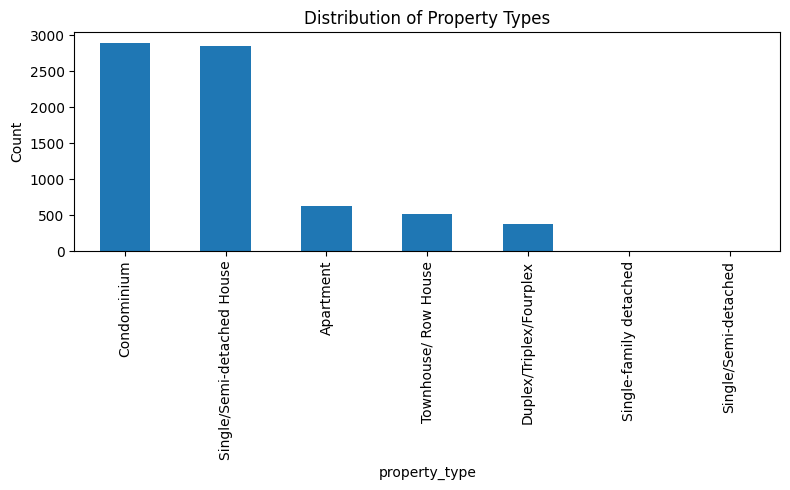

In [7]:
property_counts = df['property_type'].value_counts()

# Examine the overall distribution of property types
plt.figure(figsize=(8,5))
property_counts.plot(kind='bar')

plt.title("Distribution of Property Types")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [8]:
# Calculate the percentage share of total short-term rental listings
# for each ward to understand relative concentration.
ward_counts = df['ward_name'].value_counts()

ward_percent = ward_counts / ward_counts.sum() * 100
ward_percent = ward_percent.sort_values(ascending=False)

ward_percent.head(10)

ward_name
Spadina-Fort York      30.647383
Toronto Centre         10.454545
University-Rosedale     8.443526
Davenport               6.501377
Toronto-Danforth        4.931129
Parkdale-High Park      4.531680
Beaches-East York       4.214876
Etobicoke-Lakeshore     4.035813
Willowdale              3.140496
Toronto-St. Paul's      2.713499
Name: count, dtype: float64

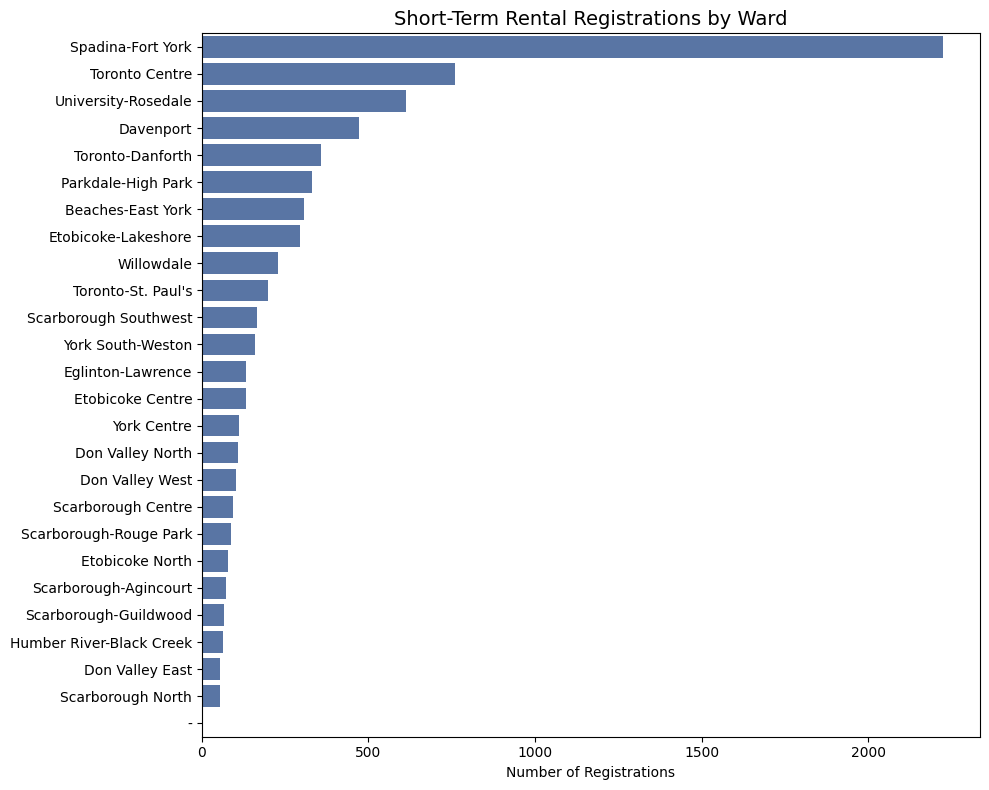

In [ ]:
ward_counts = df['ward_name'].value_counts().reset_index()
ward_counts.columns = ['ward_name', 'count']
# Count the number of short-term rental registrations per ward
# and convert the result from a Series to a DataFrame for visualization

plt.figure(figsize=(10,8))
#visualize the distribution of short-term rental registrations across Toronto wards.

sns.barplot(
    data=ward_counts,
    y='ward_name',
    x='count',
    color='#4C72B0'
)

plt.title("Short-Term Rental Registrations by Ward", fontsize=14)
plt.xlabel("Number of Registrations")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [10]:
# Create a cross-tabulation of ward and property type
# to examine how housing categories vary across wards.
cross_tab = pd.crosstab(df['ward_name'], df['property_type'])
cross_tab.head()

property_type,Apartment,Condominium,Duplex/Triplex/Fourplex,Single-family detached,Single/Semi-detached,Single/Semi-detached House,Townhouse/ Row House
ward_name,,,,,,,
-,0,0,0,0,0,0,3
Beaches-East York,18,6,21,0,0,250,11
Davenport,42,22,83,0,0,275,50
Don Valley East,2,12,1,0,0,33,7
Don Valley North,2,7,4,0,0,88,8


In [11]:
# Normalize the ward × property type table by row (index)
# so that each ward's property types sum to 100%.
cross_percent = pd.crosstab(
    df['ward_name'],
    df['property_type'],
    normalize='index'
) * 100

cross_percent.head()

property_type,Apartment,Condominium,Duplex/Triplex/Fourplex,Single-family detached,Single/Semi-detached,Single/Semi-detached House,Townhouse/ Row House
ward_name,,,,,,,
-,0.000000,0.000000,0.000000,0.0,0.0,0.000000,100.000000
Beaches-East York,5.882353,1.960784,6.862745,0.0,0.0,81.699346,3.594771
Davenport,8.898305,4.661017,17.584746,0.0,0.0,58.262712,10.593220
Don Valley East,3.636364,21.818182,1.818182,0.0,0.0,60.000000,12.727273
Don Valley North,1.834862,6.422018,3.669725,0.0,0.0,80.733945,7.339450


In [12]:
# high-concentration wards for deeper housing composition analysis.
top_wards = ward_percent.head(5).index

top_cross = cross_percent.loc[top_wards]
top_cross

property_type,Apartment,Condominium,Duplex/Triplex/Fourplex,Single-family detached,Single/Semi-detached,Single/Semi-detached House,Townhouse/ Row House
ward_name,,,,,,,
Spadina-Fort York,8.988764,81.033708,1.797753,0.0,0.0,3.415730,4.764045
Toronto Centre,13.175231,62.977602,3.030303,0.0,0.0,8.827404,11.989460
University-Rosedale,13.866232,35.725938,11.256117,0.0,0.0,31.810767,7.340946
Davenport,8.898305,4.661017,17.584746,0.0,0.0,58.262712,10.593220
Toronto-Danforth,6.703911,3.631285,7.821229,0.0,0.0,74.022346,7.821229


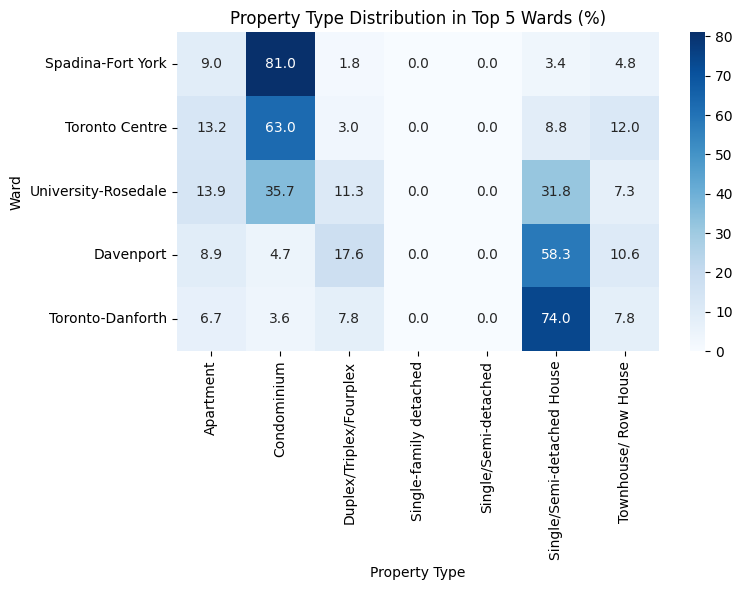

In [13]:

# Visualize property type composition in the top five wards using a heatmap.
# Percent values highlight differences in housing structure across
plt.figure(figsize=(8,6))

sns.heatmap(
    top_cross,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Property Type Distribution in Top 5 Wards (%)")
plt.ylabel("Ward")
plt.xlabel("Property Type")

plt.tight_layout()
plt.show()